Valores críticos: [4.54, 5.46]
Error Tipo II (β): 0.429
Potencia de la prueba: 0.571


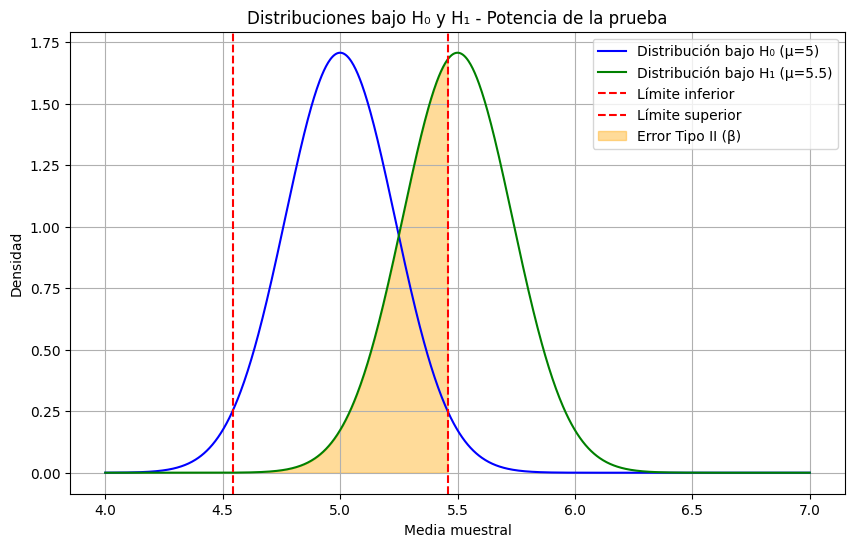

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros conocidos
mu0 = 5           # Media bajo H0
mu1 = 5.5         # Media alternativa bajo H1
sigma = 1.28      # Desviación estándar muestral (estimada)
n = 30            # Tamaño de muestra
alpha = 0.05      # Nivel de significancia

# 1. Error estándar
se = sigma / np.sqrt(n)

# 2. Valores críticos bajo H0 para prueba bilateral
z_alpha = norm.ppf(1 - alpha/2)  # 1.96 para α = 0.05
lim_inf = mu0 - z_alpha * se
lim_sup = mu0 + z_alpha * se

print(f"Valores críticos: [{lim_inf:.2f}, {lim_sup:.2f}]")

# 3. Probabilidad de aceptar H0 bajo H1 → Error tipo II (β)
# Calculamos área bajo H1 dentro del intervalo de aceptación de H0
beta = norm.cdf(lim_sup, loc=mu1, scale=se) - norm.cdf(lim_inf, loc=mu1, scale=se)
potencia = 1 - beta

print(f"Error Tipo II (β): {beta:.3f}")
print(f"Potencia de la prueba: {potencia:.3f}")

# 4. Gráfico comparativo
x = np.linspace(4, 7, 1000)
y_H0 = norm.pdf(x, loc=mu0, scale=se)
y_H1 = norm.pdf(x, loc=mu1, scale=se)

plt.figure(figsize=(10, 6))
plt.plot(x, y_H0, label='Distribución bajo H₀ (μ=5)', color='blue')
plt.plot(x, y_H1, label='Distribución bajo H₁ (μ=5.5)', color='green')

# Región crítica bajo H0
plt.axvline(lim_inf, color='red', linestyle='--', label='Límite inferior')
plt.axvline(lim_sup, color='red', linestyle='--', label='Límite superior')

# Rellenar error tipo II (β)
x_beta = np.linspace(lim_inf, lim_sup, 1000)
y_beta = norm.pdf(x_beta, loc=mu1, scale=se)
plt.fill_between(x_beta, y_beta, color='orange', alpha=0.4, label='Error Tipo II (β)')

plt.title("Distribuciones bajo H₀ y H₁ - Potencia de la prueba")
plt.xlabel("Media muestral")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True)
plt.show()

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
(244, 7)


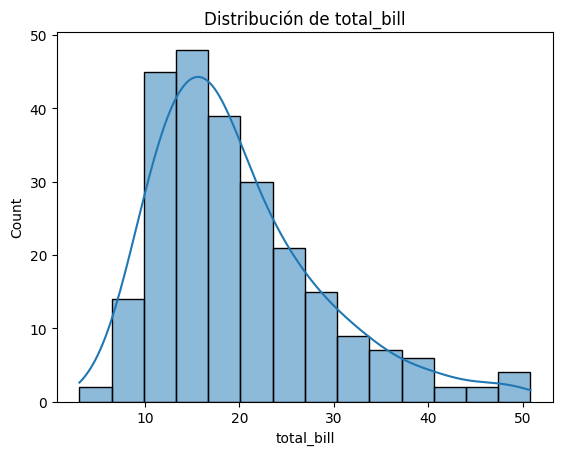

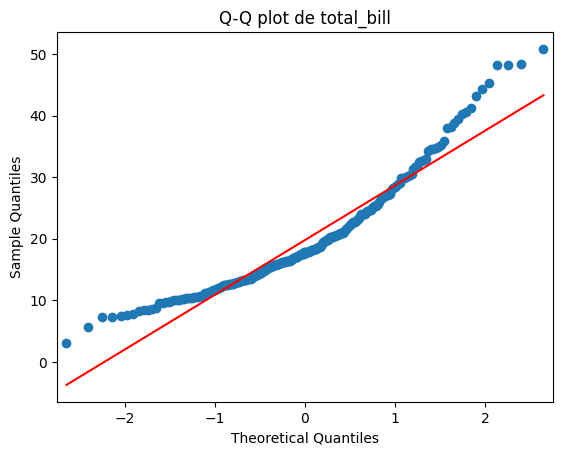

Shapiro-Wilk p-valor = 0.0000
Los datos no parecen seguir una distribución normal (se rechaza H0).


In [ ]:
# Ejemplo completo de pruebas de hipótesis (T-student, dos medias y ANOVA)
# Paso 1: Importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.power import TTestIndPower

# Paso 2: Cargar datos reales (propinas)
df = sns.load_dataset("tips")
print(df.head())
df.shape
print(df.shape)

# Paso 2: Verificación del supuesto de normalidad para la variable total_bill
# Histograma
sns.histplot(df['total_bill'], kde=True)
plt.title("Distribución de total_bill")
plt.show()

# Q-Q Plot
sm.qqplot(df['total_bill'], line='s')
plt.title("Q-Q plot de total_bill")
plt.show()

# Prueba de Shapiro-Wilk
# H0: La variable total_bill sigue una distribución Normal
# H1: La variable total_bill no sigue una distribución normal
stat, p = stats.shapiro(df['total_bill'])
print(f"Shapiro-Wilk p-valor = {p:.4f}")
if p > 0.05:
    print("Los datos parecen seguir una distribución normal (no se rechaza H0).")
else:
    print("Los datos no parecen seguir una distribución normal (se rechaza H0).")

In [ ]:
# Paso 3: Prueba de igualdad de varianzas entre sex para la variable tip
female_tip = df[df['sex'] == 'Female']['tip']
male_tip = df[df['sex'] == 'Male']['tip']

# Prueba de Levene
# H0: Varianza1=Varianza2
# H1: Varianza 1 distinto de la varianza 2
stat, p = stats.levene(female_tip, male_tip)
print(f"Levene p-valor = {p:.4f}")
if p > 0.05:
    print("Varianzas iguales (no se rechaza H0)")
else:
    print("Varianzas distintas (se rechaza H0)")




Levene p-valor = 0.1595
Varianzas iguales (no se rechaza H0)


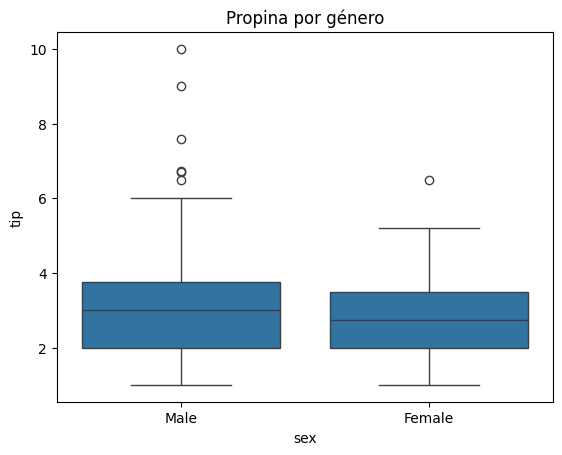

In [ ]:
# Paso 4: Boxplot para comparar tip entre sexos
sns.boxplot(data=df, x='sex', y='tip')
plt.title("Propina por género")
plt.show()

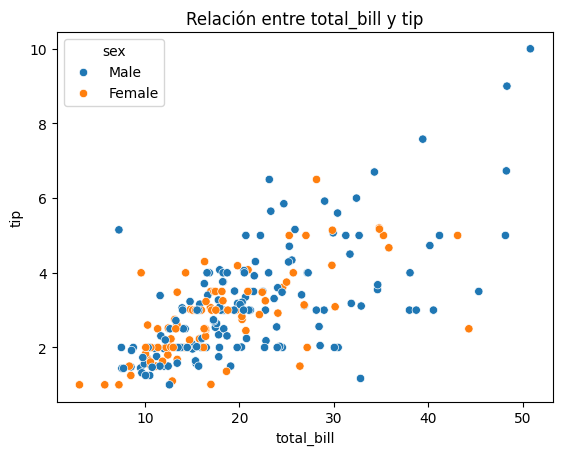

Coeficiente de correlación de Pearson: 0.68 (p = 0.0000)


In [ ]:
# Paso 5: Gráfico de dispersión entre total_bill y tip + correlación
sns.scatterplot(data=df, x='total_bill', y='tip', hue='sex')
plt.title("Relación entre total_bill y tip")
plt.show()

# Correlación de Pearson
corr, p = stats.pearsonr(df['total_bill'], df['tip'])
print(f"Coeficiente de correlación de Pearson: {corr:.2f} (p = {p:.4f})")

1. total_bill	float	Cuenta total del cliente, en dólares. Incluye comida + bebida.
2. tip	float 2. Propina dejada por el cliente, en dólares.
3. sex	category Género del mesero que atendió: 'Male' o 'Female'.
4. smoker	category	Si el cliente era fumador: 'Yes' o 'No'.
5. day	category	Día de la semana en que ocurrió la comida: 'Thur', 'Fri', 'Sat', 'Sun'.
6. time	category	Momento del día: 'Lunch' o 'Dinner'.
7. size	int	Número de personas en la mesa (tamaño del grupo).

In [ ]:
# Paso 3: Prueba de hipótesis para una media
# H0: la media de 'tip' es igual a 3
# H1: la media de 'tip' es distinta de 3
media_esperada = 3
t_stat, p_valor = stats.ttest_1samp(df['tip'], media_esperada)
print(f"Prueba T para una media:\nEstadístico t = {t_stat:.4f}, p-valor = {p_valor:.4f}\n")
# Prueba T para una media: Se evalúa si la media de propinas es distinta de 3. Un p-valor bajo (< 0.05) rechaza la hipótesis nula.
# No se rechaza H0, no hay suficiente evidencia estadística para concluir que la propina sea distinta de 3$

Prueba T para una media:
Estadístico t = -0.0194, p-valor = 0.9845



In [ ]:
# Paso 4: Prueba de hipótesis para dos medias (hombres vs mujeres)
tip_male = df[df['sex'] == 'Male']['tip']
tip_female = df[df['sex'] == 'Female']['tip']
t_stat2, p_valor2 = stats.ttest_ind(tip_male, tip_female)
print(f"Prueba T para dos medias (Hombres vs Mujeres):\nEstadístico t = {t_stat2:.4f}, p-valor = {p_valor2:.4f}\n")
# Prueba T para dos medias: Compara propinas entre hombres y mujeres. Si el p-valor < 0.05, hay diferencia significativa.
# el p valor> alpha=0,05 no se rechaza H0

Prueba T para dos medias (Hombres vs Mujeres):
Estadístico t = 1.3879, p-valor = 0.1665



In [ ]:
# Paso 7: Cálculo de la potencia de la prueba
# Supón que queremos detectar una diferencia media de 0.5 dólares en la propina con una desviación estándar común de 1,
# usando una muestra de 50 por grupo y α = 0.05:
# Parámetros para cálculo de potencia
effect_size = 0.5 / 1  # Diferencia de medias / desviación estándar
alpha = 0.05
power_analysis = TTestIndPower()
power = power_analysis.solve_power(effect_size=effect_size, nobs1=50, alpha=alpha, power=None, ratio=1.0, alternative='two-sided')

print(f"Potencia estimada de la prueba: {power:.3f}")

Potencia estimada de la prueba: 0.697


In [ ]:
# Paso 5: Prueba de ANDEVA-ANOVA, para más de dos grupos (día de la semana)
# Hipótesis nula (H₀): La media de propinas es igual para todos los días.
# Hipótesis alternativa (H₁): Al menos un día tiene una media de propina diferente.
modelo = ols('tip ~ day', data=df).fit()
anova = sm.stats.anova_lm(modelo, typ=2)
# typ=2 es suma de cuadrados de tipo 2, es la que se usa cuando las interacciones son son importantes.
# el efecto del días Jueves sobre la propina promedio y lo comparamos con el efecto que tiene el día Viernes
# sobre la propina promedio. Efecto conujunto (Jueves-Viernes sobre la propina)
print("ANOVA - Comparación de propinas por día de la semana:\n")
print(anova)
# ANOVA: Verifica si al menos un día tiene una media de propinas diferente. Se usa cuando hay más de dos grupos.
# No hay diferencia significativa entre las medias de las propinas por días.
# No se rechazó H0, el factor día no es significativo al 5%, ¿pero que pasaría si se hubiera rechazado H0?
# No nos informa cuales son los días que realmente difieren


ANOVA - Comparación de propinas por día de la semana:

              sum_sq     df         F    PR(>F)
day         9.525873    3.0  1.672355  0.173589
Residual  455.686604  240.0       NaN       NaN


Días disponibles: ['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, object): ['Thur', 'Fri', 'Sat', 'Sun']


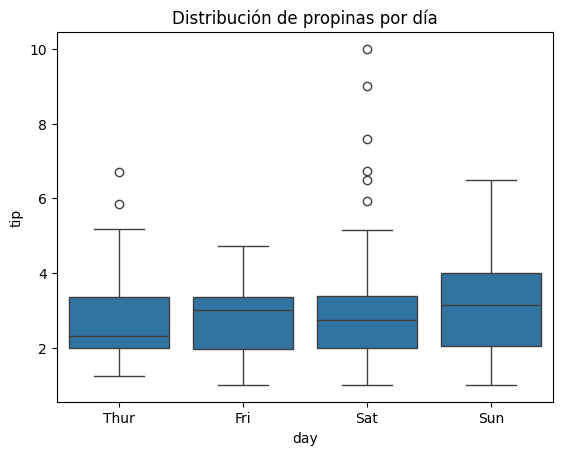

In [ ]:
# Paso 1: Importar librerías
import seaborn as sns
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Paso 2: Cargar datos
tips = sns.load_dataset('tips')

# Paso 3: Verificar valores únicos en 'day'
print("Días disponibles:", tips['day'].unique())

# Paso 4: Boxplot de propinas por día
sns.boxplot(x='day', y='tip', data=tips)
plt.title("Distribución de propinas por día")
plt.show()

In [ ]:
# Paso 5: Agrupar las propinas por día
groups = [tips[tips['day'] == day]['tip'] for day in tips['day'].unique()]

In [ ]:
# Paso 6: Prueba ANOVA (one-way)
f_stat, p_val = stats.f_oneway(*groups)
print(f"Estadístico F: {f_stat:.4f}")
print(f"Valor-p: {p_val:.4f}")

# Interpretación
alpha = 0.05
if p_val < alpha:
    print("Se rechaza H₀: Hay diferencia significativa en las propinas entre los días.")
else:
    print("No se rechaza H₀: No hay evidencia de diferencias en las propinas entre los días.")

Estadístico F: 1.6724
Valor-p: 0.1736
No se rechaza H₀: No hay evidencia de diferencias en las propinas entre los días.


Tarea a realizar:
Variables disponibles:
species: especie del pingüino (Adelie, Chinstrap, Gentoo)

island: isla donde fue encontrado

bill_length_mm: largo del pico en mm

bill_depth_mm: profundidad del pico en mm

flipper_length_mm: largo de la aleta en mm

body_mass_g: peso corporal en gramos

sex: sexo del pingüino
Objetivo: Determinar si existe diferencia significativa en el largo del pico entre dos especies de pingüinos.

Realiza un análisis exploratorio de los datos.

Aplica una prueba de hipótesis para comparar el largo del pico (bill_length_mm) entre Adelie y Gentoo.

Interpreta los resultados y concluye si hay evidencia estadística de diferencia.

Formulación de hipótesis
a) Plantea las hipótesis nula y alternativa para comparar el largo del pico entre dos especies seleccionadas.

b) ¿Cuál es la hipótesis apropiada si se desea saber si Adelie tiene picos más cortos que Gentoo?

2. Comparaciones adicionales
c) Realiza una comparación del peso corporal (body_mass_g) entre Chinstrap y Gentoo. ¿Existe diferencia significativa?

d) ¿La isla donde habitan los pingüinos influye en el largo del pico? Realiza un ANOVA de una vía (species o island como factor).

3. Validación de supuestos
e) Verifica el supuesto de normalidad para la variable bill_length_mm con gráficos (histograma y Q-Q plot).

f) Evalúa si se cumple el supuesto de igualdad de varianzas entre especies antes de aplicar la prueba T.

4. Visualización y análisis
g) Crea un gráfico de cajas (boxplot) para visualizar las diferencias en flipper_length_mm entre las especies.

h) Crea un gráfico de dispersión entre bill_length_mm y flipper_length_mm. ¿Hay alguna correlación visual?

5. Prueba de hipótesis para dos proporciones (avanzada)
i) Compara la proporción de pingüinos machos y hembras entre dos especies. ¿Hay evidencia de diferencia significativa?

6. Potencia de la prueba (nivel avanzado)
j) Supón que la verdadera diferencia de medias en bill_length_mm entre dos especies es 2 mm. Calcula la potencia de la prueba con un tamaño de muestra de 40 y una desviación estándar estimada.

In [ ]:
# Paso 1: Cargar dataset
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Cargar datos
df = sns.load_dataset("penguins")
print(df.head())

# Paso 2: Eliminar valores nulos
df = df.dropna(subset=["species", "bill_length_mm"])

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  
